<a href="https://colab.research.google.com/github/jubidr/Marketing_Campaign_DA/blob/main/mrktng_cmpgn_da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2360]:
import pandas as pd
import matplotlib.pyplot as plt
import logging
from pathlib import Path

pd.set_option('display.max_columns', 200)

logging.basicConfig(
    level=logging.INFO,
    format=' %(levelname)s - %(asctime)s - %(message)s'
)

logger = logging.getLogger(__name__)

BASE_DIR = Path.cwd()

def load_dataset(file_name, sep='\t'):
  path = BASE_DIR / file_name

  if not path.exists():
    logger.error(f'missing file: {file_name}')
    return None
  return pd.read_csv(path, sep=sep)

 **1. Discovery**

In [2361]:
df = load_dataset('marketing_campaign.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [2362]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


In [2363]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [2364]:
df.shape

(2240, 29)

In [2365]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [2366]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

**2. Handling Missing Data**

In [2367]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [2368]:
df["Income"] = df["Income"].fillna(df["Income"].median())

**3. Data Type Correction**

In [2369]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [2370]:
#Dt_Customer is object, it should be datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Dt_Customer"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2240 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 17.6 KB


**4.Duplicate Removal**

In [2371]:
df["ID"].duplicated().sum()

np.int64(0)

In [2372]:
df[df.duplicated(keep=False)]
#no duplicates!

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [2373]:
#2ncycle = Masters
df['Education'] = df['Education'].replace('2n Cycle', 'Master')

**5.Basic Data Structuring and some Visualizations**

In [2374]:
#this shows the average income for each education category
df.groupby("Education")["Income"].mean()

#Graduation avg income had a slightly more difference than Master avg income

,Income
Education,
Basic,20306.259259
Graduation,52707.305679
Master,51051.640489
PhD,56096.303498


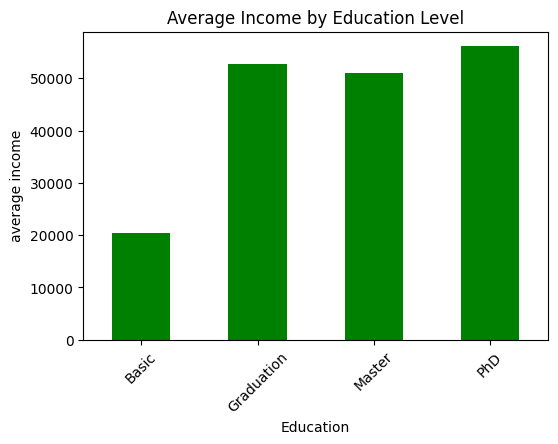

In [2375]:
incomess = df.groupby("Education")["Income"].mean()

plt.title('Average Income by Education Level')
incomess.plot(kind='bar', figsize=(6,4), color="green")
plt.ylabel('average income')
plt.xticks(rotation=45)
plt.show()

In [2376]:
luxuries = ["Income", "MntWines", "MntGoldProds"]
luxuries_edu_lvl = df.groupby("Education")[luxuries].mean()
luxuries_edu_lvl
#surprisingly PhD prioritizes spending on wine than gold
#although graduation has less avg income than Phd they spend more on Gold than PhD

,Income,MntWines,MntGoldProds
Education,,,
Basic,20306.259259,7.240741,22.833333
Graduation,52707.305679,284.268855,50.849157
Master,51051.640489,285.286213,42.523560
PhD,56096.303498,404.495885,32.310700


In [2377]:
meatss = ["MntMeatProducts", "MntFishProducts", "MntGoldProds"]
meatss_edu_lvl = df.groupby("Education")[meatss].mean()
meatss_edu_lvl
#although graduation group have less income that Phd, they are spending actively on meat products
#The overall graduation group has higher spending than all other groups

,MntMeatProducts,MntFishProducts,MntGoldProds
Education,,,
Basic,11.444444,17.055556,22.833333
Graduation,179.488909,43.149956,50.849157
Master,155.541012,37.549738,42.523560
PhD,168.602881,26.728395,32.310700


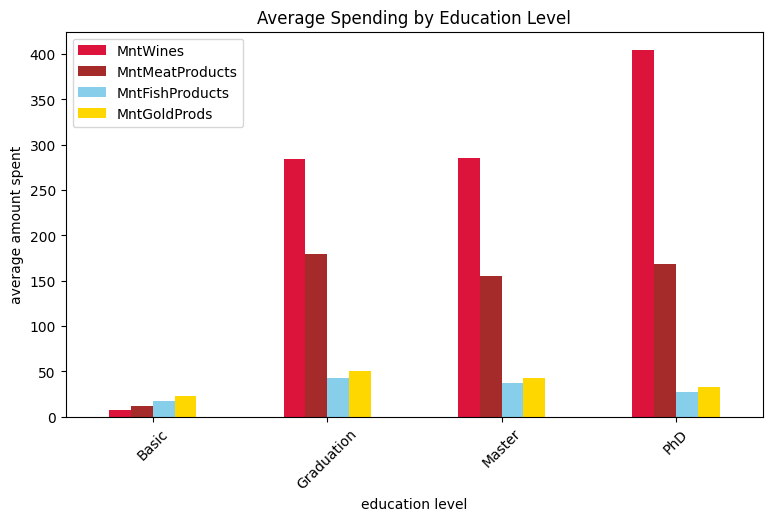

In [2378]:
edu_cols = ['MntWines', 'MntMeatProducts', 'MntFishProducts', 'MntGoldProds']
edu_colors = ['crimson', 'brown', 'skyblue', 'gold']

df.groupby('Education')[edu_cols].mean().plot(
    kind='bar',
    figsize=(9,5),
    color=edu_colors,
    rot=45,
    title='Average Spending by Education Level',
    xlabel='education level',
    ylabel='average amount spent'
)
plt.show()

In [2379]:
#this shows avg of how the total number of children affect spending habits in different food categories
df['Total_kids'] = df['Kidhome'] + df['Teenhome']
food_products = ["MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts"]

kids_spending = df.groupby('Total_kids')[food_products].mean()
kids_spending
#when going from 2 kids to 3 kids, the amount of spendings increased except in MntMeatProducts
#this means that when the number of family memebers increase the amount spent on MntMeatProducts increases regardless of the cost

,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts
Total_kids,,,,
0,52.357367,372.609718,76.547022,53.061129
1,19.352837,98.628546,26.640957,20.295213
2,7.878860,51.299287,11.387173,8.370546
3,6.905660,64.018868,7.075472,6.622642


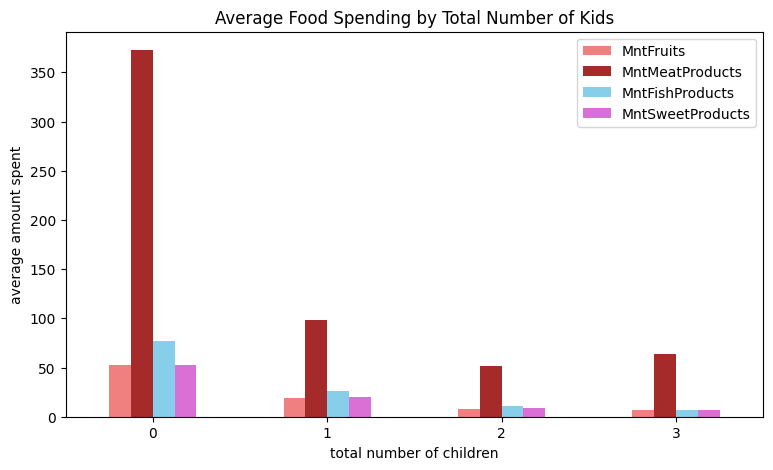

In [2380]:
food_colors=['lightcoral', 'brown', 'skyblue', 'orchid']

kids_spending.plot(
    kind='bar',
    figsize=(9,5),
    color=food_colors,
    rot=0,
    title='Average Food Spending by Total Number of Kids',
    xlabel='total number of children',
    ylabel='average amount spent'
)
plt.show()

In [2381]:
df.groupby('Total_kids')["NumDealsPurchases"].mean()
#group with 0 kids doesnt depend on deals for their purchases, so they spend alot regardless of deals
#group with 2 or 3 kids are likely only buying when their is adiscoount or special offer

,NumDealsPurchases
Total_kids,
0,1.139498
1,2.467199
2,3.555819
3,3.792453


In [2382]:
#summing the campaign columns to know the total number of successes for each "Marital_Status" category
df.groupby("Marital_Status")[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Marital_Status,,,,,,
Absurd,1,0,0,0,1,1
Alone,0,0,1,0,0,1
Divorced,12,5,20,18,13,48
Married,63,7,63,63,66,98
Single,31,5,38,33,31,106
Together,32,12,37,43,44,60
Widow,5,1,4,10,8,19
YOLO,0,0,0,0,0,1


**6.Text Cleaning**

In [2383]:
df["Education"] = df["Education"].str.strip().str.lower()
df["Marital_Status"] = df["Marital_Status"].str.strip().str.lower()

In [2384]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [2385]:
df.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'complain', 'z_costcontact', 'z_revenue', 'response',
       'total_kids'],
      dtype='object')

In [2386]:
df.sample(2)

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response,total_kids
474,9081,1988,graduation,single,20518.0,1,0,2014-05-18,58,4,1,6,4,1,9,1,1,1,2,5,0,0,0,0,0,0,3,11,0,1
582,5081,1967,master,together,47821.0,1,1,2013-10-20,54,9,0,16,6,6,10,1,1,0,3,8,0,0,0,0,0,0,3,11,0,2


**7.Final Export**

In [2387]:
df.to_csv('marketing_camp2.csv', index=False, sep='\t')


In [2388]:
df2 = load_dataset('marketing_camp2.csv')
df2.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response,total_kids
0,5524,1957,graduation,single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,0
1,2174,1954,graduation,single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,2
2,4141,1965,graduation,together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,0
3,6182,1984,graduation,together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,1
4,5324,1981,phd,married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,1
